# RLHF Results

Run all cells to generate paper figures and full results for all scenarios.

In [ ]:
import json
import os
import re
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [ ]:
# ============================================
# Configuration
# ============================================
SCRATCH_DIR = "/work/hdd/bfwm/phu1/Project"
out_dir = f"{SCRATCH_DIR}/Dr.Post-Training/RLHF"
config_dir = './train/configs/toxicity'
save_dir = './figures'
os.makedirs(save_dir, exist_ok=True)

def load_yaml_config(config_dir, method_name=None):
    """Load defaults.yaml, optionally overlaid with method config."""
    cfg = {}
    defaults_path = os.path.join(config_dir, 'defaults.yaml')
    if os.path.exists(defaults_path):
        with open(defaults_path) as f:
            cfg.update(yaml.safe_load(f))
    if method_name:
        method_path = os.path.join(config_dir, f'{method_name}.yaml')
        if os.path.exists(method_path):
            with open(method_path) as f:
                method_cfg = yaml.safe_load(f)
                if method_cfg:
                    cfg.update(method_cfg)
    return cfg

# Load shared defaults
shared_config = load_yaml_config(config_dir)
task = shared_config.get('task', 'toxicity')
model = os.path.basename(shared_config.get('model', 'gpt-neo-2.7B'))
print(f"Loaded config from {config_dir}/defaults.yaml")
print(f"Task: {task}, Model: {model}")

# Methods
ALL_METHODS = ['Standard-LoRA', 'IIF-LoRA', 'Layerwise-LoRA', 'Subset-LoRA']

LEGEND_NAMES = {
    'Standard-LoRA': 'Standard',
    'IIF-LoRA': 'IIF',
    'Layerwise-LoRA': 'Layer-wise',
    'Subset-LoRA': 'Subset',
}

METHOD_COLORS = {
    'Standard-LoRA': 'black',
    'IIF-LoRA': 'blue',
    'Layerwise-LoRA': 'red',
    'Subset-LoRA': 'green',
}

# All scenarios
SCENARIOS = {
    'self-ref / avg-reward':   {'n_val': 0,    'val_loss_type': 'seqloss-reward'},
    'self-ref / full-ppo':     {'n_val': 0,    'val_loss_type': 'ppo'},
    'self-ref / pre-clip-ppo': {'n_val': 0,    'val_loss_type': 'tokenpg'},
    'held-out / avg-reward':   {'n_val': 1024, 'val_loss_type': 'seqloss-reward'},
    'held-out / pre-clip-ppo': {'n_val': 1024, 'val_loss_type': 'tokenpg'},
}

VAL_TYPE_SHORT = {'seqloss-lastadv': 'adv', 'seqloss-reward': 'rew', 'tokenpg': 'tpg', 'ppo': 'ppo'}

print(f"Scenarios: {len(SCENARIOS)}")
print(f"Methods: {', '.join(ALL_METHODS)}")

## Helper Functions & Load All Data

In [ ]:
# ============================================
# Helper functions (parameterized by scenario)
# ============================================

_config_cache = {}

def _method_config(method_name):
    """Load merged config (defaults + method overrides) from YAML."""
    if method_name not in _config_cache:
        _config_cache[method_name] = load_yaml_config(config_dir, method_name)
    return _config_cache[method_name]

def _lr(method_name):
    cfg = _method_config(method_name)
    val = cfg.get('learning_rate', 1e-5)
    return f'{val:.0e}' if val < 0.001 else f'{val}'

def _kl(method_name):
    cfg = _method_config(method_name)
    return cfg.get('init_kl_coef', 0.02)

def _dir_name(method_name, seed, scfg):
    """Build directory name for a method + scenario + seed."""
    cfg = _method_config(method_name)
    method, finetuning = method_name.split('-', 1)
    lr = _lr(method_name)
    kl_coef = _kl(method_name)
    vlt_short = VAL_TYPE_SHORT.get(scfg['val_loss_type'], scfg['val_loss_type'])
    val_str = f"v{scfg['n_val']}-{vlt_short}"
    if scfg['n_val'] > 0:
        val_str = f"{val_str}-b{cfg.get('val_batch_size', 256)}"
    return (f"{task}-{model}-{method}-{finetuning}"
            f"-lr{lr}-b{cfg.get('batch_size', 256)}-{val_str}"
            f"-pe{cfg.get('ppo_epochs', 4)}-mb{cfg.get('mini_batch_size', 4)}"
            f"-kl{kl_coef}-s{seed}")

def _discover_seeds(method_name, scfg):
    pattern = _dir_name(method_name, '*', scfg)
    seeds = []
    for p in glob(f"{out_dir}/{pattern}"):
        m = re.search(r'-s(\d+)$', Path(p).name)
        if m:
            seeds.append(int(m.group(1)))
    return sorted(seeds)

def _load_history(path):
    with open(path, 'r') as f:
        h = json.load(f)
    n = len(h.get('reward', []))
    return {
        'steps': np.arange(n),
        'reward_mean': np.array(h.get('reward', [])),
        'kl': np.array(h.get('kl', [])),
        'batch_toxicity': np.array(h.get('toxicity_prob', [])),
        'eval_toxicity_steps': np.array(h.get('full_eval_steps', [])),
        'eval_toxicity': np.array(h.get('full_eval_toxicity_prob', [])),
    }

def _load_log(path):
    steps, rewards, kls, btox = [], [], [], []
    etox, etox_steps = [], []
    with open(path, 'r') as f:
        for line in f:
            if 'Step ' in line and 'Eval step' not in line:
                try:
                    sm = re.search(r'Step (\d+):', line)
                    if not sm: continue
                    step = int(sm.group(1))
                    metrics = None
                    if '{' in line:
                        try:
                            metrics = json.loads(line[line.index('{'):line.rindex('}')+1].replace("'", '"'))
                        except: pass
                    if metrics is None:
                        metrics = {}
                        for k, v in re.findall(r'(\w+)=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', line):
                            val = float(v)
                            if k == 'reward': metrics['reward/mean'] = val
                            elif k == 'kl': metrics['objective/kl'] = val
                            elif k == 'tox': metrics['eval/toxicity_prob'] = val
                    if metrics:
                        steps.append(step)
                        rewards.append(metrics.get('reward/mean', 0))
                        kls.append(metrics.get('objective/kl', 0))
                        btox.append(metrics.get('eval/toxicity_prob', 0))
                except: continue
            elif '[Eval step' in line and 'toxicity:' in line:
                try:
                    m = re.search(r'\[Eval step (\d+)\] toxicity: ([\d.]+)', line)
                    if m: etox_steps.append(int(m.group(1))); etox.append(float(m.group(2)))
                except: continue
    return {
        'steps': np.array(steps), 'reward_mean': np.array(rewards),
        'kl': np.array(kls), 'batch_toxicity': np.array(btox),
        'eval_toxicity_steps': np.array(etox_steps), 'eval_toxicity': np.array(etox),
    }

def _load_exp(exp_path):
    for fname, loader, src in [('training_history.json', _load_history, 'history'), ('train.log', _load_log, 'log')]:
        p = f"{exp_path}/{fname}"
        if Path(p).exists():
            try: return loader(p), src
            except Exception as e: print(f"  Warning: {p}: {e}")
    return None, None

def load_method(method_name, scfg):
    """Load and aggregate results across seeds for a method + scenario."""
    seeds = _discover_seeds(method_name, scfg)
    if not seeds: return None
    all_res, valid_seeds = [], []
    for seed in seeds:
        result, _ = _load_exp(f"{out_dir}/{_dir_name(method_name, seed, scfg)}")
        if result is not None and len(result['steps']) > 0:
            all_res.append(result); valid_seeds.append(seed)
    if not all_res: return None
    ml = min(len(r['steps']) for r in all_res)
    def _s(k): return np.stack([r[k][:ml] for r in all_res])
    reward, kl, btox = _s('reward_mean'), _s('kl'), _s('batch_toxicity')
    eml = min(len(r['eval_toxicity']) for r in all_res) if all(len(r['eval_toxicity']) > 0 for r in all_res) else 0
    if eml > 0:
        etox = np.stack([r['eval_toxicity'][:eml] for r in all_res])
        etox_steps = all_res[0]['eval_toxicity_steps'][:eml]
    else:
        etox, etox_steps = np.array([]).reshape(0,0), np.array([])
    return {
        'steps': all_res[0]['steps'][:ml],
        'reward_mean_mean': np.mean(reward, 0), 'reward_mean_std': np.std(reward, 0),
        'kl_mean': np.mean(kl, 0), 'kl_std': np.std(kl, 0),
        'batch_toxicity_mean': np.mean(btox, 0), 'batch_toxicity_std': np.std(btox, 0),
        'eval_toxicity_steps': etox_steps,
        'eval_toxicity_mean': np.mean(etox, 0) if eml > 0 else np.array([]),
        'eval_toxicity_std': np.std(etox, 0) if eml > 0 else np.array([]),
        'n_seeds': len(valid_seeds), 'seeds': valid_seeds,
    }

# ============================================
# Load ALL scenarios upfront
# ============================================
# all_data[scenario_name][method_name] = {...}
all_data = {}

for sname, scfg in SCENARIOS.items():
    sdata = {}
    for method_name in ALL_METHODS:
        data = load_method(method_name, scfg)
        if data:
            sdata[method_name] = data
    all_data[sname] = sdata
    found = len(sdata)
    seeds_info = ""
    if sdata:
        first = next(iter(sdata.values()))
        seeds_info = f", seeds={first['seeds']}"
    print(f"  {sname}: {found}/{len(ALL_METHODS)} methods{seeds_info}")

print(f"\nAll {len(all_data)} scenarios loaded.")

## Paper Figures: Reward + Eval Toxicity (per scenario)

Two publication-ready plots per scenario: Reward vs Round, Eval Toxicity vs Round.


  self-ref / avg-reward

  [self-ref / avg-reward] reward
    + Standard-LoRA: 5 seeds
    + IIF-LoRA: 5 seeds
    + Layerwise-LoRA: 5 seeds
    + Subset-LoRA: 5 seeds
    -> Saved: ./figures/rlhf_self-ref_avg-reward_reward.pdf


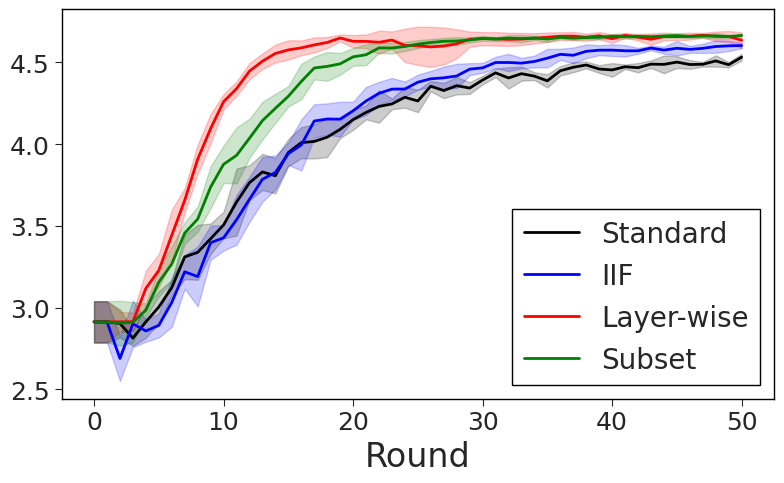


  [self-ref / avg-reward] eval_tox
    + Standard-LoRA: 5 seeds
    + IIF-LoRA: 5 seeds
    + Layerwise-LoRA: 5 seeds
    + Subset-LoRA: 5 seeds
    -> Saved: ./figures/rlhf_self-ref_avg-reward_eval_tox.pdf


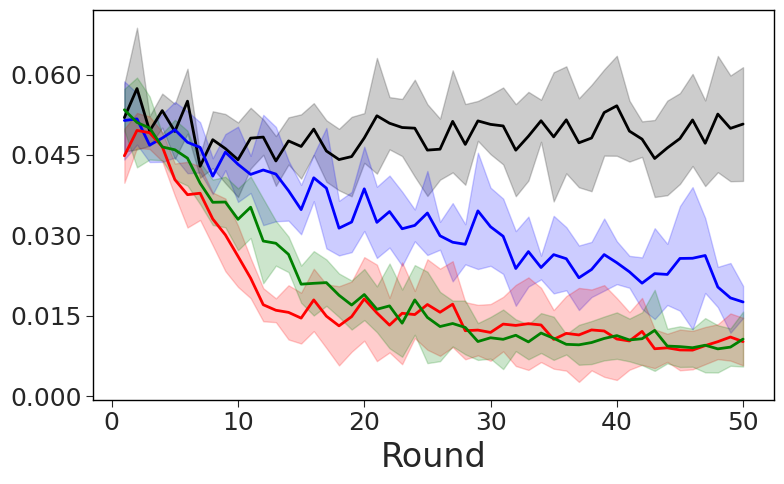


  self-ref / full-ppo

  [self-ref / full-ppo] reward
    + Standard-LoRA: 5 seeds
    + IIF-LoRA: 5 seeds
    + Layerwise-LoRA: 5 seeds
    + Subset-LoRA: 5 seeds
    -> Saved: ./figures/rlhf_self-ref_full-ppo_reward.pdf


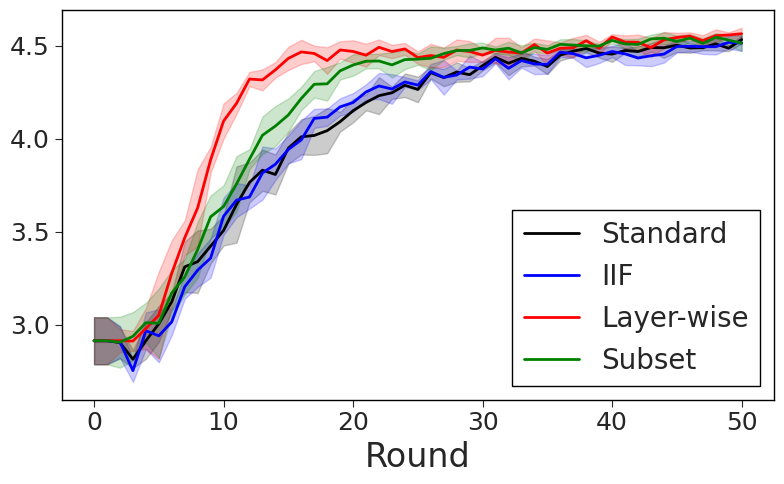


  [self-ref / full-ppo] eval_tox
    + Standard-LoRA: 5 seeds
    + IIF-LoRA: 5 seeds
    + Layerwise-LoRA: 5 seeds
    + Subset-LoRA: 5 seeds
    -> Saved: ./figures/rlhf_self-ref_full-ppo_eval_tox.pdf


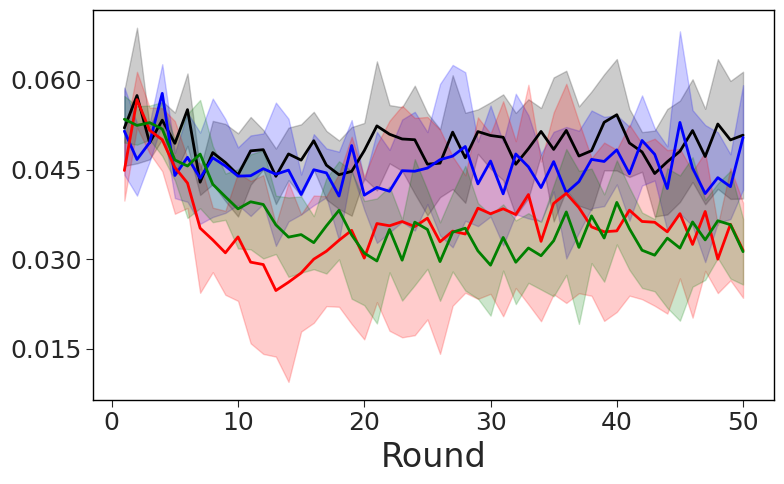


  self-ref / pre-clip-ppo

  [self-ref / pre-clip-ppo] reward
    + Standard-LoRA: 5 seeds
    + IIF-LoRA: 5 seeds
    + Layerwise-LoRA: 5 seeds
    + Subset-LoRA: 5 seeds
    -> Saved: ./figures/rlhf_self-ref_pre-clip-ppo_reward.pdf


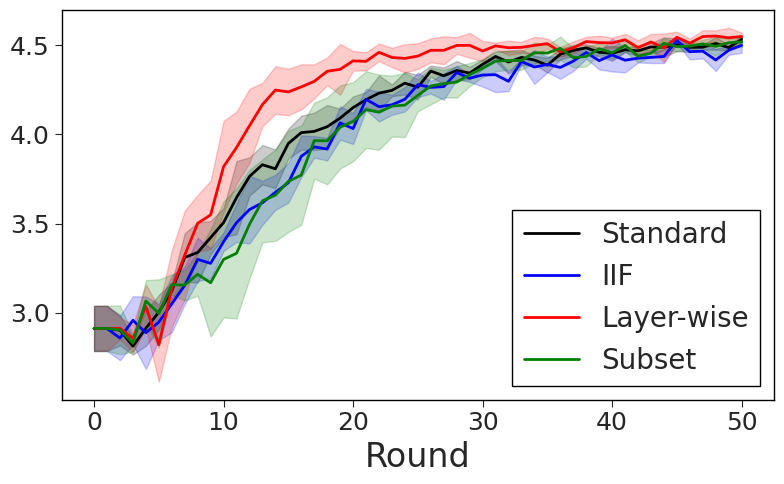


  [self-ref / pre-clip-ppo] eval_tox
    + Standard-LoRA: 5 seeds
    + IIF-LoRA: 5 seeds
    + Layerwise-LoRA: 5 seeds
    + Subset-LoRA: 5 seeds
    -> Saved: ./figures/rlhf_self-ref_pre-clip-ppo_eval_tox.pdf


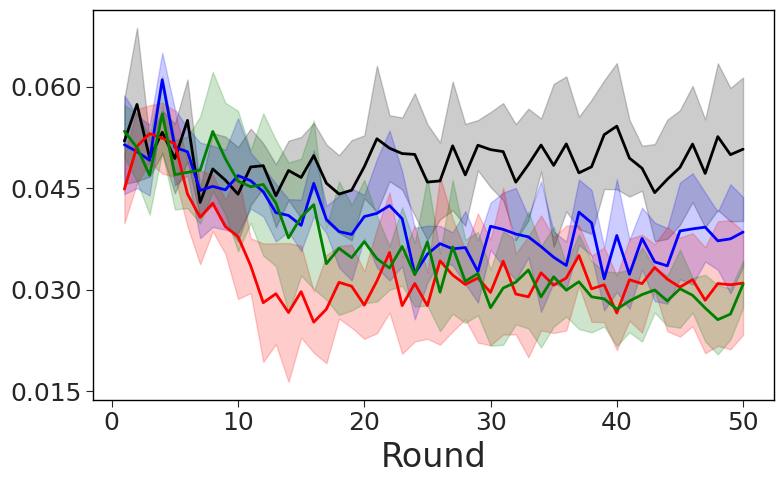


  held-out / avg-reward

  [held-out / avg-reward] reward
    + Standard-LoRA: 5 seeds
    + IIF-LoRA: 5 seeds
    + Layerwise-LoRA: 5 seeds
    + Subset-LoRA: 5 seeds
    -> Saved: ./figures/rlhf_held-out_avg-reward_reward.pdf


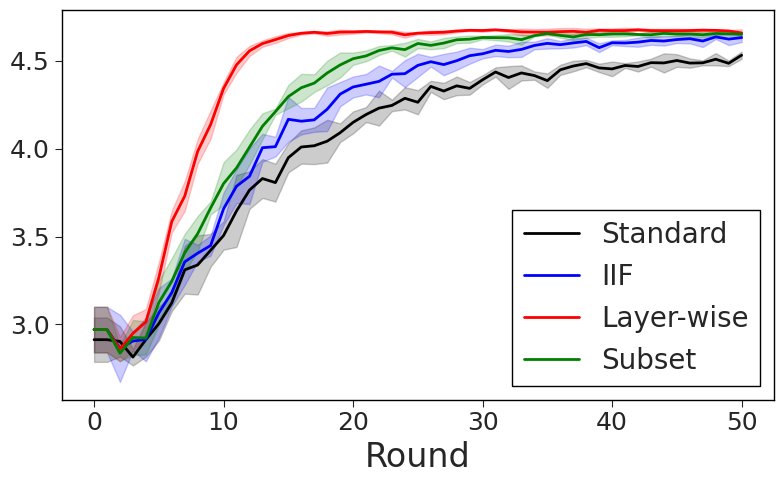


  [held-out / avg-reward] eval_tox
    + Standard-LoRA: 5 seeds
    + IIF-LoRA: 5 seeds
    + Layerwise-LoRA: 5 seeds
    + Subset-LoRA: 5 seeds
    -> Saved: ./figures/rlhf_held-out_avg-reward_eval_tox.pdf


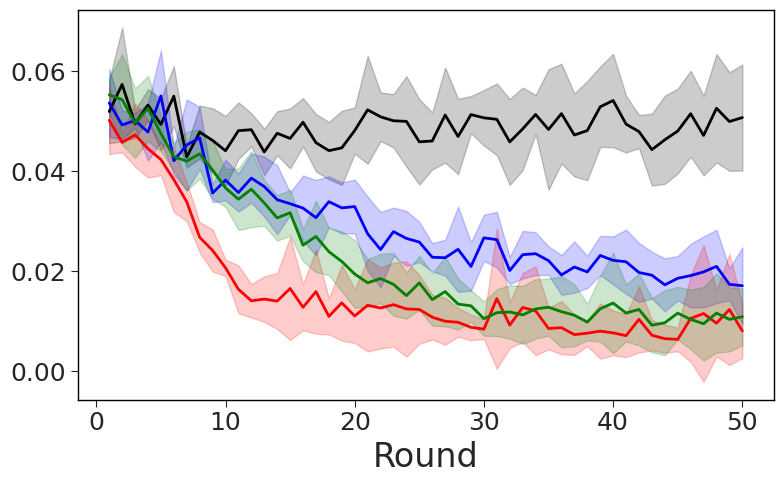


  held-out / pre-clip-ppo

  [held-out / pre-clip-ppo] reward
    + Standard-LoRA: 5 seeds
    + IIF-LoRA: 5 seeds
    + Layerwise-LoRA: 5 seeds
    + Subset-LoRA: 5 seeds
    -> Saved: ./figures/rlhf_held-out_pre-clip-ppo_reward.pdf


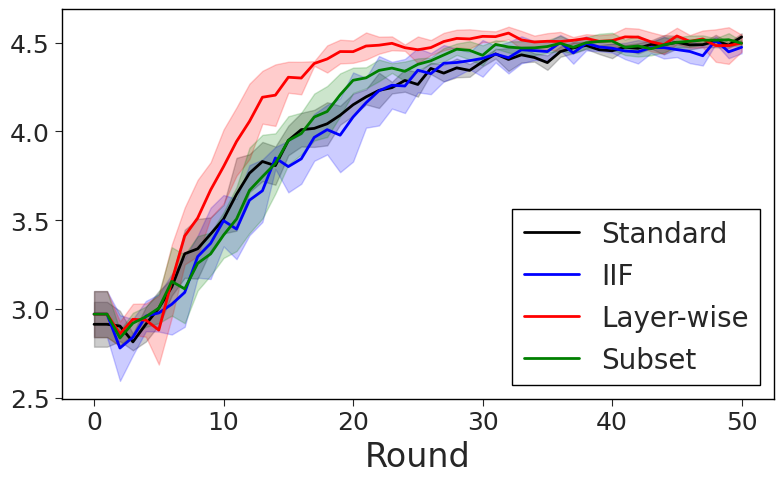


  [held-out / pre-clip-ppo] eval_tox
    + Standard-LoRA: 5 seeds
    + IIF-LoRA: 5 seeds
    + Layerwise-LoRA: 5 seeds
    + Subset-LoRA: 5 seeds
    -> Saved: ./figures/rlhf_held-out_pre-clip-ppo_eval_tox.pdf


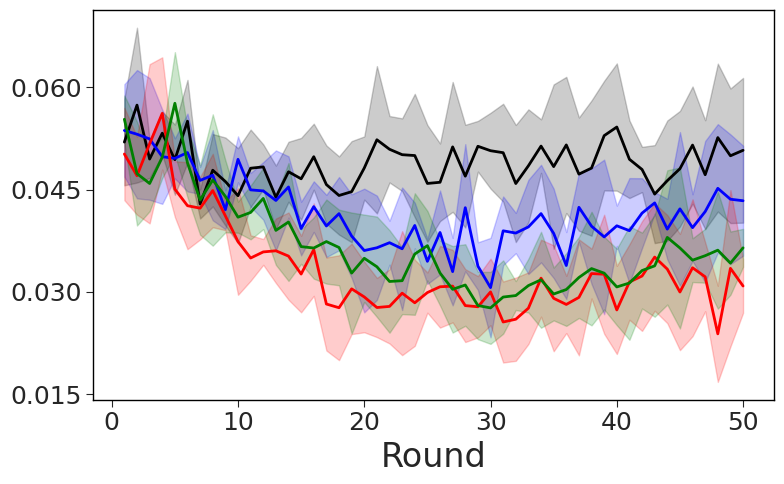

In [4]:
# Paper figures: Reward + Eval Toxicity for each scenario
max_step = 50  # Set to None for all steps

PAPER_PLOTS = [
    {'key': 'reward', 'x': lambda d: d['steps'], 'y': lambda d: d['reward_mean_mean'],
     'std': lambda d: d['reward_mean_std'], 'x_label': 'Round', 'show_legend': True},
    {'key': 'eval_tox', 'x': lambda d: d['eval_toxicity_steps'], 'y': lambda d: d['eval_toxicity_mean'],
     'std': lambda d: d['eval_toxicity_std'], 'x_label': 'Round', 'show_legend': False},
]

for sname, scfg in SCENARIOS.items():
    sdata = all_data[sname]
    sname_safe = sname.replace(' / ', '_').replace(' ', '_')

    print(f"\n{'='*60}")
    print(f"  {sname}")
    print(f"{'='*60}")

    for pcfg in PAPER_PLOTS:
        print(f"\n  [{sname}] {pcfg['key']}")

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')

        has_data = False
        for method_name in ALL_METHODS:
            if method_name not in sdata:
                continue
            data = sdata[method_name]
            x, mean, std = pcfg['x'](data), pcfg['y'](data), pcfg['std'](data)
            if x is None or len(x) == 0 or mean is None or len(mean) == 0:
                continue
            if max_step is not None:
                mask = x <= max_step
                x, mean = x[mask], mean[mask]
                std = std[mask] if std is not None and len(std) > 0 else None

            color = METHOD_COLORS.get(method_name)
            display = LEGEND_NAMES.get(method_name, method_name)
            ax.plot(x, mean, linewidth=2, label=display, color=color)
            if std is not None and len(std) > 0 and data['n_seeds'] > 1:
                ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)
            has_data = True
            print(f"    + {method_name}: {data['n_seeds']} seeds")

        ax.set_xlabel(pcfg['x_label'], fontsize=24)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_linewidth(1.0); spine.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=18, direction='out', length=5)
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

        if has_data and pcfg['show_legend']:
            legend = ax.legend(loc='lower right', fontsize=20, frameon=True,
                              edgecolor='black', fancybox=False, framealpha=1.0)
            legend.get_frame().set_facecolor('white')
        elif not has_data:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', fontsize=15, color='gray')

        plt.tight_layout()
        filepath = os.path.join(save_dir, f"rlhf_{sname_safe}_{pcfg['key']}.pdf")
        fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
        print(f"    -> Saved: {filepath}")
        plt.show()

## All Scenarios: Comparison Grid + Summary Tables

Saved: ./figures/rlhf_all_scenarios.pdf


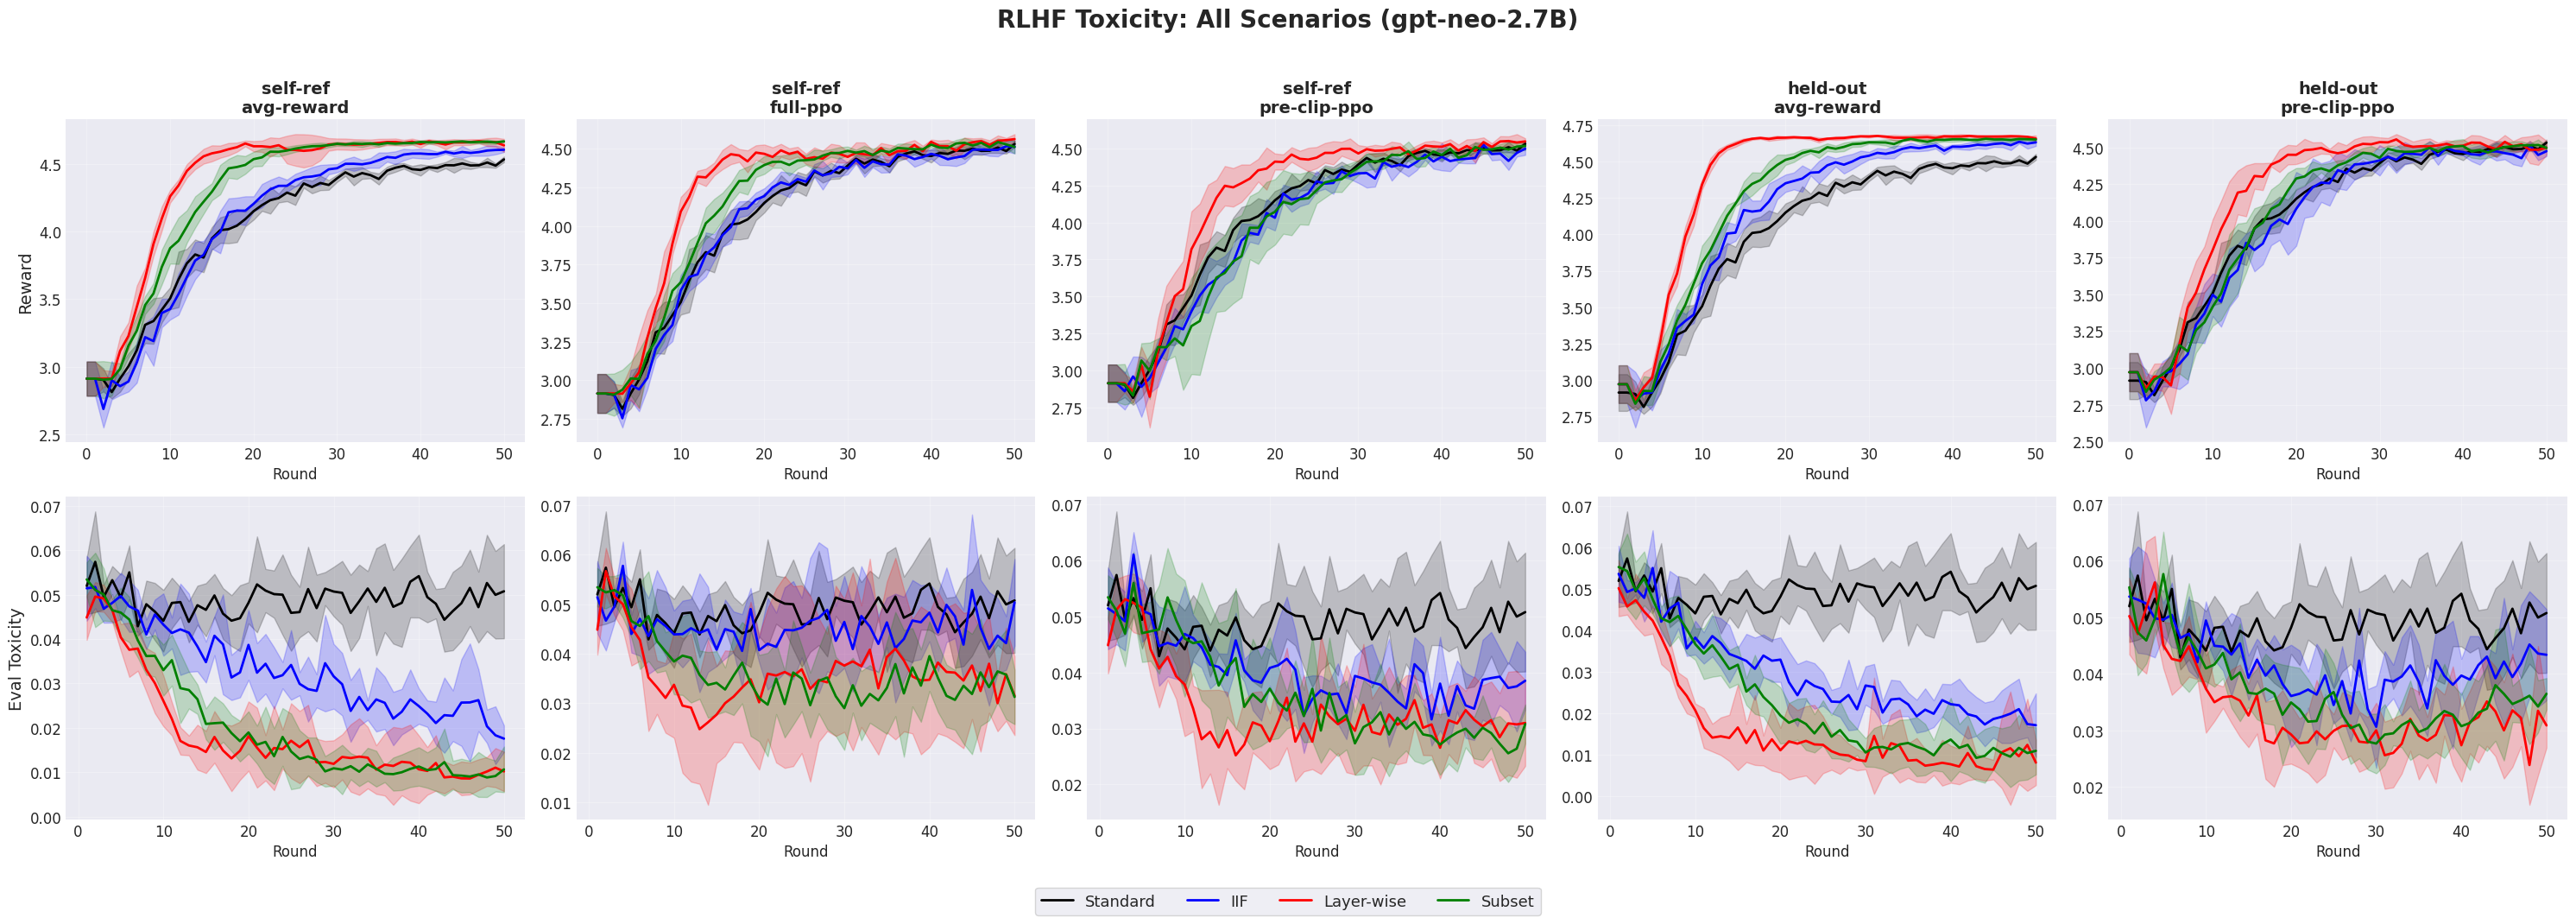


  self-ref / avg-reward
Method               Seeds   Reward                 Batch Tox              Eval Tox              
-----------------------------------------------------------------------------------------------
Standard-LoRA        5       4.5430 +/- 0.0360      0.0693 +/- 0.0139      0.0538 +/- 0.0112     
IIF-LoRA             5       4.6410 +/- 0.0069      0.0259 +/- 0.0111      0.0155 +/- 0.0050     
Layerwise-LoRA       5       4.6345 +/- 0.0626      0.0112 +/- 0.0067      0.0082 +/- 0.0049     
Subset-LoRA          5       4.6779 +/- 0.0084      0.0153 +/- 0.0080      0.0132 +/- 0.0071     

  self-ref / full-ppo
Method               Seeds   Reward                 Batch Tox              Eval Tox              
-----------------------------------------------------------------------------------------------
Standard-LoRA        5       4.5430 +/- 0.0360      0.0693 +/- 0.0139      0.0538 +/- 0.0112     
IIF-LoRA             5       4.5609 +/- 0.0522      0.0590 +/- 0.0156     

In [5]:
# ============================================
# All-scenarios comparison grid (2 rows x N cols)
# ============================================
scenario_names = list(SCENARIOS.keys())
n_scenarios = len(scenario_names)

fig, axes = plt.subplots(2, n_scenarios, figsize=(6 * n_scenarios, 10))
fig.suptitle(f'RLHF Toxicity: All Scenarios ({model})', fontsize=20, fontweight='bold', y=1.02)

for col, sname in enumerate(scenario_names):
    sdata = all_data.get(sname, {})
    for method_name in ALL_METHODS:
        if method_name not in sdata: continue
        data = sdata[method_name]
        color = METHOD_COLORS.get(method_name)
        display = LEGEND_NAMES.get(method_name, method_name)

        x, mean, std = data['steps'], data['reward_mean_mean'], data['reward_mean_std']
        if max_step is not None:
            mask = x <= max_step; x, mean, std = x[mask], mean[mask], std[mask]
        axes[0, col].plot(x, mean, linewidth=2, color=color, label=display)
        if data['n_seeds'] > 1: axes[0, col].fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

        ex, emean, estd = data['eval_toxicity_steps'], data['eval_toxicity_mean'], data['eval_toxicity_std']
        if len(ex) > 0:
            if max_step is not None:
                emask = ex <= max_step; ex, emean, estd = ex[emask], emean[emask], estd[emask]
            axes[1, col].plot(ex, emean, linewidth=2, color=color, label=display)
            if data['n_seeds'] > 1: axes[1, col].fill_between(ex, emean - estd, emean + estd, color=color, alpha=0.2)

    axes[0, col].set_title(sname.replace(' / ', '\n'), fontsize=14, fontweight='bold')
    axes[0, col].set_xlabel('Round', fontsize=12); axes[1, col].set_xlabel('Round', fontsize=12)
    axes[0, col].grid(True, alpha=0.3); axes[1, col].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Reward', fontsize=14)
axes[1, 0].set_ylabel('Eval Toxicity', fontsize=14)

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.04),
               ncol=len(ALL_METHODS), fontsize=13, frameon=True, fancybox=True)
plt.tight_layout(); plt.subplots_adjust(bottom=0.08)
filepath = os.path.join(save_dir, 'rlhf_all_scenarios.pdf')
fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
print(f"Saved: {filepath}")
plt.show()


# ============================================
# Summary tables: per scenario + cross-scenario
# ============================================
for sname in scenario_names:
    sdata = all_data.get(sname, {})
    if not sdata: continue
    print(f"\n{'='*95}")
    print(f"  {sname}")
    print(f"{'='*95}")
    print(f"{'Method':<20} {'Seeds':<7} {'Reward':<22} {'Batch Tox':<22} {'Eval Tox':<22}")
    print("-" * 95)
    for name in ALL_METHODS:
        if name not in sdata: continue
        d = sdata[name]; n = d['n_seeds']
        def _f(arr): return f"{arr[-1]:.4f} +/- {0:.4f}" if n == 1 else f"{arr[-1]:.4f}" if len(arr) == 0 else f"{arr[-1]:.4f}"
        r = d['reward_mean_mean']; rs = d['reward_mean_std']
        bt = d['batch_toxicity_mean']; bts = d['batch_toxicity_std']
        et = d['eval_toxicity_mean']; ets = d['eval_toxicity_std']
        r_str = f"{r[-1]:.4f} +/- {rs[-1]:.4f}" if n > 1 else f"{r[-1]:.4f}"
        bt_str = f"{bt[-1]:.4f} +/- {bts[-1]:.4f}" if n > 1 and len(bt) > 0 else f"{bt[-1]:.4f}" if len(bt) > 0 else "N/A"
        et_str = f"{et[-1]:.4f} +/- {ets[-1]:.4f}" if n > 1 and len(et) > 0 else f"{et[-1]:.4f}" if len(et) > 0 else "N/A"
        print(f"{name:<20} {n:<7} {r_str:<22} {bt_str:<22} {et_str:<22}")
    print("=" * 95)

# Cross-scenario comparison
print(f"\n{'='*130}")
print(f"Cross-Scenario: Final Reward / Eval Toxicity")
print(f"{'='*130}")
print(f"{'Method':<20}", end="")
for sname in scenario_names:
    short = sname.split(' / ')[1] if ' / ' in sname else sname
    print(f" {short:>12} / {'tox':>6} |", end="")
print()
print("-" * 130)
for method_name in ALL_METHODS:
    display = LEGEND_NAMES.get(method_name, method_name)
    print(f"{display:<20}", end="")
    for sname in scenario_names:
        sdata = all_data.get(sname, {})
        if method_name in sdata:
            d = sdata[method_name]
            r = d['reward_mean_mean'][-1] if len(d['reward_mean_mean']) > 0 else float('nan')
            t = d['eval_toxicity_mean'][-1] if len(d['eval_toxicity_mean']) > 0 else float('nan')
            print(f" {r:12.4f} / {t:6.4f} |", end="")
        else:
            print(f" {'N/A':>12} / {'N/A':>6} |", end="")
    print()
print("=" * 130)